In [1]:
import os
import random

import pandas as pd
import polars as pl
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
# Declare  variables, working directory and dataset directory
MODE = 'reduced_features'
NUM_EPOCHS = 100
START_EPOCH = 0
NUM_ITEMS = 1_000_000
BATCH_SIZE = 128
DROPOUT_RATE = 0.5
L1_lambda = 0.005
L2_lambda = 0.001

WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank'
DATASET_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/dataset'

MODEL_MODE = "dol1l2" # regular (reg), dropout (do), dropout + l1l2 (dol1l2)
PREFIX = f"{MODEL_MODE}-leakyrelu-lrscheduler-{DROPOUT_RATE}"
SUFFIX = f"{NUM_ITEMS}-{NUM_EPOCHS}-{BATCH_SIZE}-{L1_lambda}-{L2_lambda}"

CHECKPOINT_NAME = os.path.join(WORKING_DIR, 'output', 'model', MODE, f'{PREFIX}-checkpoint-{SUFFIX}.pt')

INPUT_SIZE = 200

print(CHECKPOINT_NAME)

/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/output/model/reduced_features/dol1l2-leakyrelu-lrscheduler-0.5-checkpoint-1000000-100-128-0.005-0.001.pt


In [3]:
def get_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    if device.type == "cuda":
        print(f"Current CUDA device: {torch.cuda.current_device()}")
        print(f"CUDA device name: {torch.cuda.get_device_name(0)}")

    return device

In [4]:
device = get_device()

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB


In [5]:
class BinaryClassifierDropOutL1L2(nn.Module):
    def __init__(self, input_size, hidden1_size=64, hidden2_size=32, output_size=1, dropout_rate=0.2, l1_lambda=0.001, l2_lambda=0.001):
        super(BinaryClassifierDropOutL1L2, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1_size),
            # nn.ReLU(),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden1_size, hidden2_size),
            # nn.ReLU(),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden2_size, output_size),
            nn.Sigmoid()
        )

        self.l1_lambda = l1_lambda
        self.l2_lambda = l2_lambda

    def forward(self, x):
        # x = x.squeeze(1)
        outputs = self.network(x)
        l1_reg = torch.tensor(0., requires_grad=True)
        l2_reg = torch.tensor(0., requires_grad=True)

        for name, param in self.named_parameters():
            if 'weight' in name:
                l1_reg = l1_reg + torch.linalg.norm(param, 1)
                l2_reg = l2_reg + torch.linalg.norm(param, 2)

        return outputs, self.l1_lambda * l1_reg, self.l2_lambda * l2_reg

    def predict(self, x):
        with torch.no_grad():
            outputs, _, _ = self.forward(x)
            return (outputs >= 0.5).long()



In [6]:
class BinaryClassifierDropOut(nn.Module):
    def __init__(self, input_size, hidden1_size=64, hidden2_size=32, output_size=1, dropout_rate=0.2):
        super(BinaryClassifierDropOut, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden1_size, hidden2_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden2_size, output_size),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x = x.squeeze(1)
        return self.network(x)

    def predict(self, x):
        with torch.no_grad():
            outputs = self.forward(x)
            return (outputs >= 0.5).long()

In [7]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, num_items):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(14, 6))
    
    # Plot for training and validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'blue', label='Training Loss')
    plt.plot(epochs, val_losses, 'orange', label='Validation Loss')
    plt.title(f'Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.ylim(0.4, 0.8)
    plt.legend()
    plt.grid(True)
    
    # Plot for training and validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'blue', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'orange', label='Validation Accuracy')
    plt.title(f'Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.ylim(50, 90)
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    
    plt.show()

In [8]:
# Initialize model
if MODEL_MODE == "reg":
    model = BinaryClassifier(input_size=INPUT_SIZE).to(device)
elif MODEL_MODE == "do":
    model = BinaryClassifierDropOut(input_size=INPUT_SIZE, dropout_rate=DROPOUT_RATE).to(device)
elif MODEL_MODE == "dol1l2":
    model = BinaryClassifierDropOutL1L2(input_size=INPUT_SIZE, dropout_rate=DROPOUT_RATE, l1_lambda=L1_lambda, l2_lambda=L2_lambda).to(device)

# Define loss function for binary classification
criterion = nn.BCELoss()  # Binary Cross Entropy Loss

# Training loop example
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4, amsgrad=True)

# Define learning rate scheduler
scheduler = lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

In [9]:
print(model)

BinaryClassifierDropOutL1L2(
  (network): Sequential(
    (0): Linear(in_features=200, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [10]:
# Arrays for saving the performance metric
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []
val_precisions = []
val_recalls = []
val_f1_scores = []

In [11]:
# Check if the checkpoint exists
if os.path.exists(CHECKPOINT_NAME):
    checkpoint = torch.load(CHECKPOINT_NAME)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler'])
    START_EPOCH = checkpoint['epoch'] + 1
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    train_accuracies = checkpoint['train_accuracies']
    val_accuracies = checkpoint['val_accuracies']
    train_aucs = checkpoint['train_aucs']
    val_aucs = checkpoint['val_aucs']
    val_precisions = checkpoint['val_precisions']
    val_recalls = checkpoint['val_recalls']
    val_f1_scores = checkpoint['val_f1_scores']

    print(f"{CHECKPOINT_NAME} exists. Resuming training from epoch {START_EPOCH}.")
else:
    START_EPOCH = 0

/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/output/model/reduced_features/dol1l2-leakyrelu-lrscheduler-0.5-checkpoint-1000000-100-128-0.005-0.001.pt exists. Resuming training from epoch 100.


In [12]:
START_EPOCH

100

In [13]:
print(train_losses)
print(val_losses)

[0.6016, 0.5829, 0.5807, 0.5803, 0.5795, 0.5796, 0.5792, 0.5787, 0.5797, 0.5787, 0.579, 0.5797, 0.5806, 0.5791, 0.5788, 0.5788, 0.58, 0.5795, 0.5794, 0.5793, 0.575, 0.5746, 0.5738, 0.5746, 0.5741, 0.574, 0.5735, 0.5743, 0.5727, 0.5738, 0.5743, 0.5743, 0.5739, 0.5739, 0.5723, 0.5736, 0.5728, 0.5736, 0.5732, 0.5731, 0.5712, 0.5704, 0.57, 0.5686, 0.5687, 0.569, 0.5689, 0.5695, 0.5699, 0.5692, 0.5686, 0.5689, 0.5692, 0.5691, 0.569, 0.5692, 0.5692, 0.5685, 0.5687, 0.5685, 0.567, 0.5662, 0.5662, 0.5656, 0.5663, 0.5654, 0.5662, 0.5663, 0.5659, 0.5661, 0.5658, 0.565, 0.5646, 0.5655, 0.5643, 0.5659, 0.565, 0.5659, 0.5655, 0.5655, 0.5629, 0.5633, 0.5632, 0.5633, 0.5632, 0.5635, 0.5627, 0.5639, 0.5628, 0.5623, 0.5617, 0.5623, 0.5627, 0.5631, 0.5618, 0.5625, 0.5631, 0.5623, 0.5624, 0.5628]
[0.5886, 0.5853, 0.584, 0.5814, 0.5842, 0.582, 0.5818, 0.5798, 0.5821, 0.5795, 0.5825, 0.5821, 0.5824, 0.5828, 0.5809, 0.5819, 0.5815, 0.5804, 0.5826, 0.5787, 0.5755, 0.5758, 0.5795, 0.579, 0.5785, 0.5793, 0.576

In [14]:
print(train_accuracies)
print(val_accuracies)

[70.14, 70.75, 70.78, 70.74, 70.83, 70.81, 70.87, 70.88, 70.84, 70.86, 70.86, 70.84, 70.78, 70.88, 70.96, 70.94, 70.85, 70.86, 70.87, 70.88, 70.95, 71.03, 71.04, 71.0, 70.99, 71.06, 71.13, 71.0, 71.17, 71.07, 71.11, 71.07, 71.14, 71.04, 71.22, 71.11, 71.14, 71.11, 71.12, 71.14, 71.18, 71.17, 71.22, 71.32, 71.32, 71.29, 71.32, 71.3, 71.24, 71.25, 71.29, 71.3, 71.28, 71.23, 71.29, 71.22, 71.27, 71.29, 71.24, 71.33, 71.29, 71.39, 71.42, 71.41, 71.38, 71.49, 71.39, 71.38, 71.39, 71.39, 71.41, 71.49, 71.43, 71.43, 71.48, 71.45, 71.41, 71.35, 71.43, 71.45, 71.58, 71.56, 71.54, 71.55, 71.53, 71.57, 71.54, 71.53, 71.57, 71.55, 71.67, 71.62, 71.61, 71.52, 71.6, 71.58, 71.56, 71.63, 71.58, 71.54]
[69.85, 70.17, 69.74, 70.21, 70.21, 70.02, 70.39, 70.23, 70.33, 70.42, 70.31, 70.19, 70.31, 70.05, 70.32, 70.32, 70.28, 70.4, 70.17, 70.32, 70.43, 70.48, 70.42, 70.14, 70.5, 70.08, 70.56, 70.49, 70.32, 70.48, 70.2, 70.36, 70.41, 70.19, 70.38, 70.55, 70.56, 70.41, 70.25, 70.41, 70.81, 70.47, 70.68, 70.46

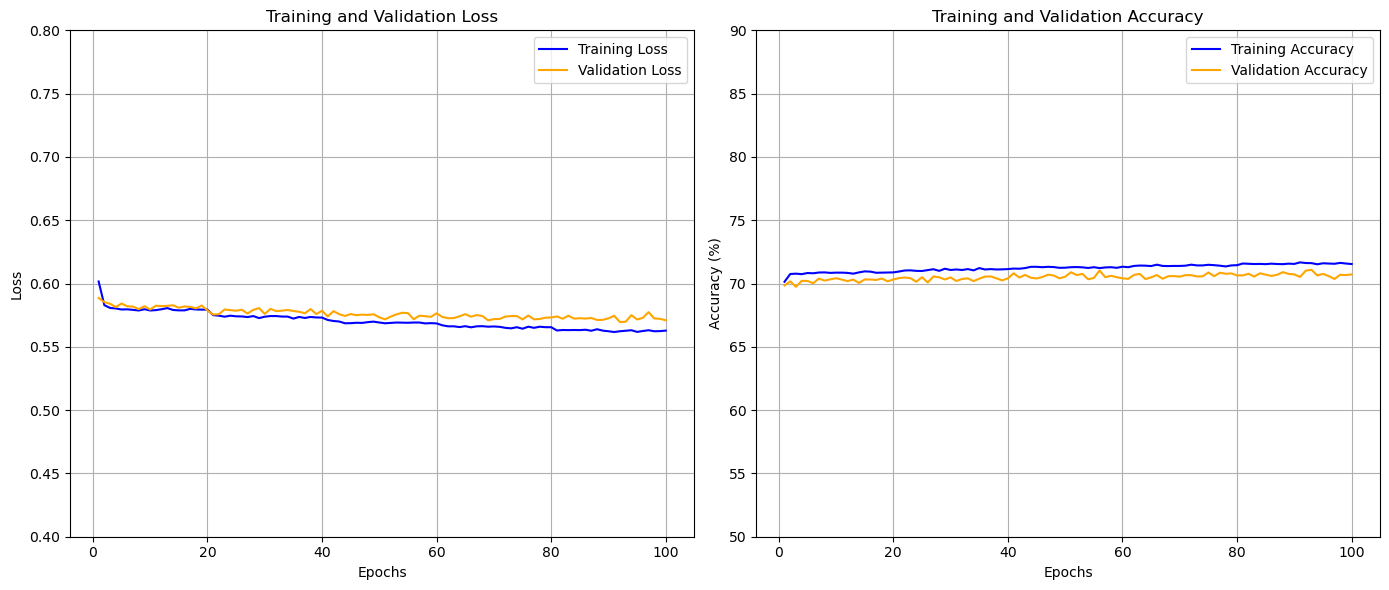

In [15]:
plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, NUM_ITEMS)